In [17]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

In [9]:
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform= transform,
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = transform
)

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

class_names = train_data.classes

#Inspecting what the data is like
print(f"Classes: {class_names}")
print(f"Training data: {len(train_data)}\nTesting Data: {len(test_data)}")
print(f"Training batches: {len(train_loader)}\nTesting batches: {len(test_loader)}")


Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training data: 60000
Testing Data: 10000
Training batches: 1875
Testing batches: 313


Batch shape: torch.Size([32, 1, 28, 28])


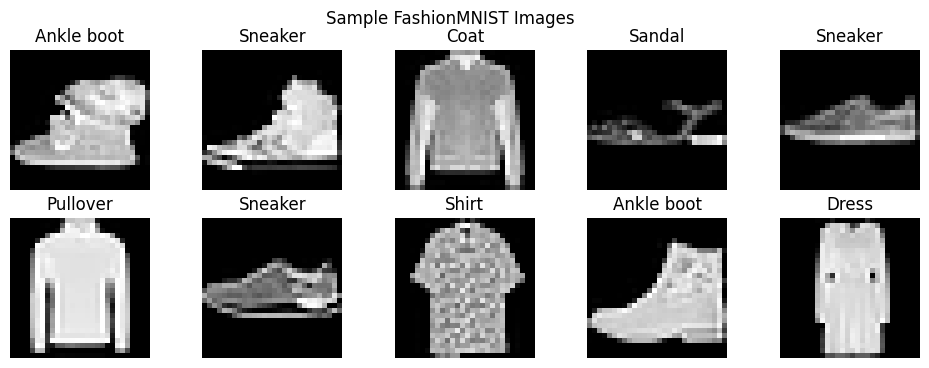

In [10]:
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}") #The output is a 4D tensor, N C H W

plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(images[i].squeeze(), cmap = 'gray')
  plt.title(class_names[labels[i]])
  plt.axis('off')

plt.suptitle("Sample FashionMNIST Images")
plt.show()

In [11]:
#building the base model
#feed forward neural network
class FashionClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), #we are using linear network, which expects 1D vector and not 2d image. Each sample would have 784 features(28 * 28) for this image
        nn.Linear(in_features = 784, out_features = 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(in_features = 256, out_features = 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(in_features = 128, out_features = 10) #equal to the number of classes
    )

  def forward(self, x):
    return self.layer_stack(x)

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = FashionClassifier().to(device)
print(model)
print(next(iter(model.parameters())).device)

FashionClassifier(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)
cuda:0


In [13]:
#setting up the loss_fn and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    params = model.parameters(),
    lr = 0.001
)

In [14]:
#training
torch.manual_seed(42)
epochs = 10
train_losses, test_losses, test_acc = [], [], []

for epoch in range(epochs):
  model.train()
  train_loss = 0
  for image, label in train_loader:
    image, label = image.to(device), label.to(device)
    y_pred = model(image)
    loss = loss_fn(y_pred, label)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  model.eval()
  test_loss, correct, total = 0,0,0
  with torch.inference_mode():
    for image, label in test_loader:
      image, label = image.to(device), label.to(device)
      output = model(image)

      test_loss += loss_fn(output, label).item()
      correct += (output.argmax(dim = 1) == label).sum().item()
      total += label.size(0)

  train_losses.append(train_loss/ len(train_loader))
  test_losses.append(test_loss/ len(test_loader))
  test_acc.append(correct/total * 100)



  print(f"Epoch {epoch+1}/10 | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | Accuracy: {test_acc[-1]:.2f}%")

Epoch 1/10 | Train Loss: 0.5511 | Test Loss: 0.4276 | Accuracy: 84.21%
Epoch 2/10 | Train Loss: 0.4128 | Test Loss: 0.3821 | Accuracy: 86.47%
Epoch 3/10 | Train Loss: 0.3758 | Test Loss: 0.3724 | Accuracy: 86.49%
Epoch 4/10 | Train Loss: 0.3532 | Test Loss: 0.3646 | Accuracy: 86.92%
Epoch 5/10 | Train Loss: 0.3405 | Test Loss: 0.3472 | Accuracy: 87.62%
Epoch 6/10 | Train Loss: 0.3269 | Test Loss: 0.3384 | Accuracy: 87.82%
Epoch 7/10 | Train Loss: 0.3160 | Test Loss: 0.3275 | Accuracy: 88.10%
Epoch 8/10 | Train Loss: 0.3070 | Test Loss: 0.3282 | Accuracy: 87.88%
Epoch 9/10 | Train Loss: 0.3025 | Test Loss: 0.3324 | Accuracy: 88.28%
Epoch 10/10 | Train Loss: 0.2936 | Test Loss: 0.3389 | Accuracy: 87.71%


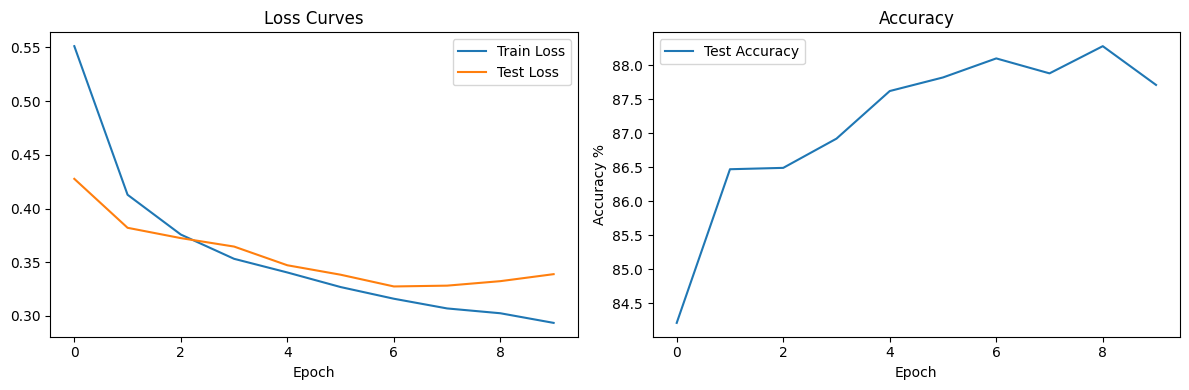

In [16]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4))
ax1.plot(train_losses, label = 'Train Loss')
ax1.plot(test_losses, label = 'Test Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(test_acc, label = 'Test Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()

plt.tight_layout()
plt.show()

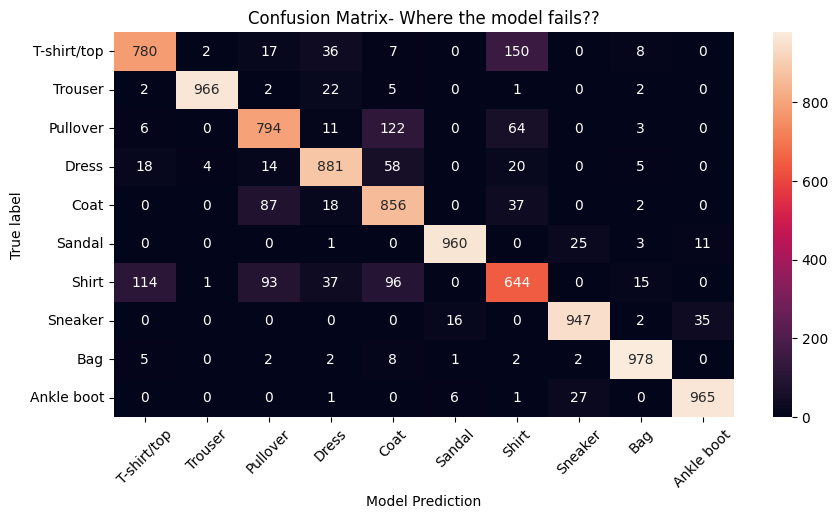

In [18]:
#visualizing where our model fails???

all_preds, all_labels = [], []
model.eval()
with torch.inference_mode():
  for image, label in test_loader:
    image = image.to(device)#cpu to gpu
    y_logit = model(image)
    y_pred = y_logit.argmax(dim =1).cpu()
    all_preds.extend(y_pred)
    all_labels.extend(label)


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize = (10,5))
sns.heatmap(cm, annot= True, fmt = 'd', xticklabels = class_names, yticklabels = class_names)
plt.title('Confusion Matrix- Where the model fails??')
plt.xlabel('Model Prediction')
plt.ylabel('True label')
plt.xticks(rotation = 45)
plt.show()